In [1]:
import pandas as pd
import numpy as np

# 1. Load the two datasets using relative paths (../ looks in the parent folder)
df_blue = pd.read_csv('../sapphire_dataset_final.csv')
df_yellow = pd.read_csv('../yellow_sapphire_dataset_final.csv')

# 2. Combine them into one master dataset
df = pd.concat([df_blue, df_yellow], ignore_index=True)

print(f"Combined dataset shape: {df.shape[0]} rows and {df.shape[1]} columns.")

# View the first few rows of raw data
df.head()

Combined dataset shape: 3999 rows and 15 columns.


,Item_ID,Total_Price,Price_Per_Carat,Weight,Length,Width,Height,Color,Intensity,Clarity,Shape,Cut,Treatment,Origin,URL
0,S11898,"$6,349","$4,070",1.56 Ct.,7.06,7.02,4.27,Blue,Vivid,Eye Clean,Round,Mixed Brilliant Cut,Heat Treated,Ceylon (Sri Lanka),https://www.thenaturalsapphirecompany.com/blue...
1,S12301,"$13,841","$4,692",2.95 Ct.,11.77,7.31,4.41,Blue,Vivid,Eye Clean,Pear,Mixed Brilliant Cut,Heat Treated,Ceylon (Sri Lanka),https://www.thenaturalsapphirecompany.com/blue...
2,S23913,"$34,660","$4,573",7.58 Ct.,11.43,11.32,7.02,Blue,Vivid,Eye Clean,Round,Modified Brilliant Cut,Heat Treated,Ceylon (Sri Lanka),https://www.thenaturalsapphirecompany.com/blue...
3,S24093,"$93,744","$5,070",18.49 Ct.,15.45,19.09,9.37,Blue,Vivid,Eye Clean,Heart,Mixed Brilliant Cut,Heat Treated,Madagascar,https://www.thenaturalsapphirecompany.com/blue...
4,S9498,"$1,330","$1,900",0.70 Ct.,5.94,4.10,3.21,Blue,Intense,Eye Clean,Oval,Mixed Brilliant Cut,Heat Treated,Ceylon (Sri Lanka),https://www.thenaturalsapphirecompany.com/blue...


In [2]:
# 3. Clean the Currency Columns 
for col in ['Total_Price', 'Price_Per_Carat']:
    df[col] = df[col].astype(str).str.replace('$', '', regex=False)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Clean the Weight Column
df['Weight'] = df['Weight'].astype(str).str.replace(' Ct.', '', regex=False)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# 5. Clean the Dimension Columns
for col in ['Length', 'Width', 'Height']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 6. Drop missing values
df = df.dropna(subset=['Total_Price', 'Price_Per_Carat', 'Weight'])

print(f"Cleaned dataset shape: {df.shape[0]} rows.")

# Save the cleaned dataset inside your data_preprocess folder
df.to_csv('master_sapphire_cleaned.csv', index=False)
print("Data cleaned and saved to master_sapphire_cleaned.csv!")

# Verify the numeric conversion
df.head()

Cleaned dataset shape: 3931 rows.
Data cleaned and saved to master_sapphire_cleaned.csv!


,Item_ID,Total_Price,Price_Per_Carat,Weight,Length,Width,Height,Color,Intensity,Clarity,Shape,Cut,Treatment,Origin,URL
0,S11898,6349.0,4070.0,1.56,7.06,7.02,4.27,Blue,Vivid,Eye Clean,Round,Mixed Brilliant Cut,Heat Treated,Ceylon (Sri Lanka),https://www.thenaturalsapphirecompany.com/blue...
1,S12301,13841.0,4692.0,2.95,11.77,7.31,4.41,Blue,Vivid,Eye Clean,Pear,Mixed Brilliant Cut,Heat Treated,Ceylon (Sri Lanka),https://www.thenaturalsapphirecompany.com/blue...
2,S23913,34660.0,4573.0,7.58,11.43,11.32,7.02,Blue,Vivid,Eye Clean,Round,Modified Brilliant Cut,Heat Treated,Ceylon (Sri Lanka),https://www.thenaturalsapphirecompany.com/blue...
3,S24093,93744.0,5070.0,18.49,15.45,19.09,9.37,Blue,Vivid,Eye Clean,Heart,Mixed Brilliant Cut,Heat Treated,Madagascar,https://www.thenaturalsapphirecompany.com/blue...
4,S9498,1330.0,1900.0,0.70,5.94,4.10,3.21,Blue,Intense,Eye Clean,Oval,Mixed Brilliant Cut,Heat Treated,Ceylon (Sri Lanka),https://www.thenaturalsapphirecompany.com/blue...


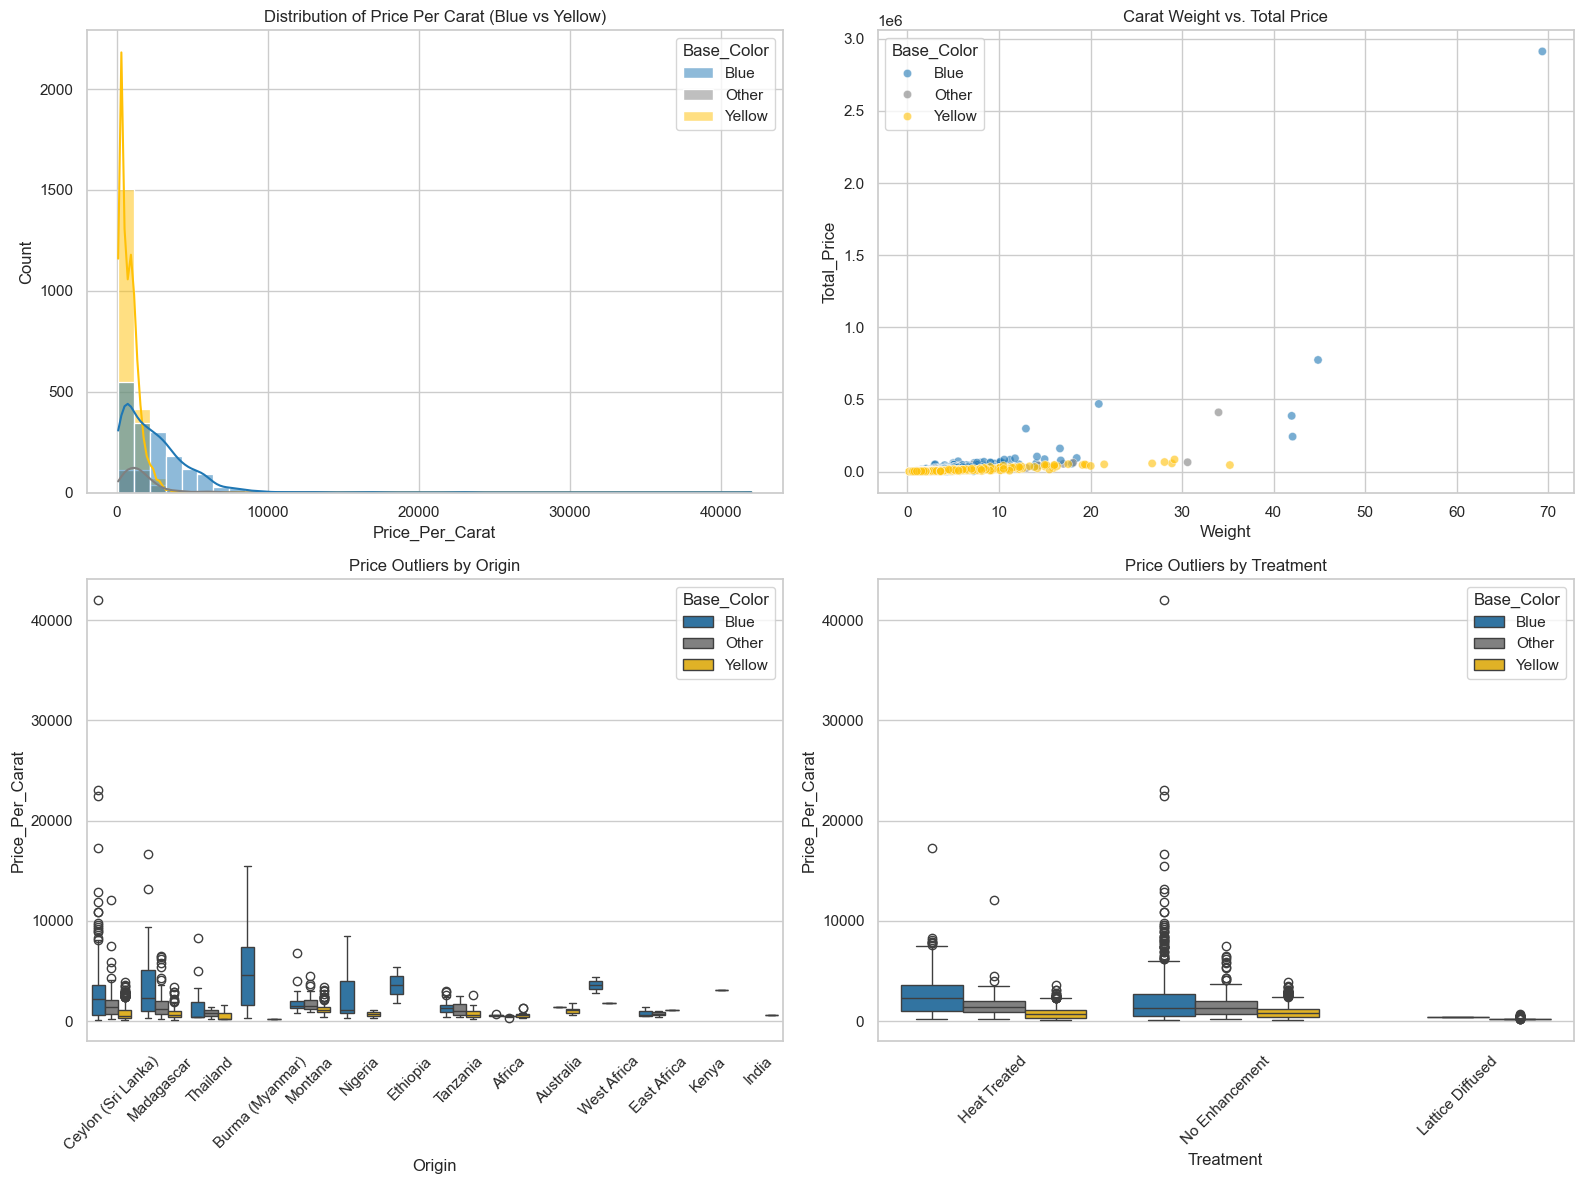

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Safely group the complex colors into broad categories for visualization
def group_color(color_str):
    color_str = str(color_str).lower()
    if 'yellow' in color_str or 'brown' in color_str or 'orange' in color_str:
        return 'Yellow'
    elif 'blue' in color_str or 'violet' in color_str or 'grey' in color_str:
        return 'Blue'
    else:
        return 'Other' # Catches things like "Color Change"

# Create a new column just for the high-level charts (keeps original 'Color' safe)
df['Base_Color'] = df['Color'].apply(group_color)

# Add 'Other' to the color map just in case
color_map = {"Blue": "#1f77b4", "Yellow": "#ffc107", "Other": "#808080"}

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Price Distribution
sns.histplot(
    data=df, 
    x='Price_Per_Carat', 
    hue='Base_Color',  # <--- Updated to use the new grouped column
    kde=True, 
    bins=40, 
    palette=color_map, 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Distribution of Price Per Carat (Blue vs Yellow)')

# 2. Weight vs. Total Price
sns.scatterplot(
    data=df, 
    x='Weight', 
    y='Total_Price', 
    hue='Base_Color',  # <--- Updated
    alpha=0.6, 
    palette=color_map, 
    ax=axes[0, 1]
)
axes[0, 1].set_title('Carat Weight vs. Total Price')

# 3. Outlier Detection by Origin
sns.boxplot(
    data=df, 
    x='Origin', 
    y='Price_Per_Carat', 
    hue='Base_Color',  # <--- Updated
    palette=color_map, 
    ax=axes[1, 0]
)
axes[1, 0].set_title('Price Outliers by Origin')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Outlier Detection by Treatment
sns.boxplot(
    data=df, 
    x='Treatment', 
    y='Price_Per_Carat', 
    hue='Base_Color',  # <--- Updated
    palette=color_map, 
    ax=axes[1, 1]
)
axes[1, 1].set_title('Price Outliers by Treatment')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# 1. Remove extreme weight outliers (Drop stones over 25 carats)
df = df[df['Weight'] <= 25]

# 2. Remove ultra-extreme price outliers (Drop stones over $20,000 per carat)
df = df[df['Price_Per_Carat'] <= 20000]

# 3. Group rare origins into an 'Other' category to prevent model overfitting
# Count how many times each origin appears
origin_counts = df['Origin'].value_counts()

# Find the names of origins that appear less than 20 times
rare_origins = origin_counts[origin_counts < 20].index

# Replace those rare origin names with 'Other'
df['Origin'] = df['Origin'].apply(lambda x: 'Other' if x in rare_origins else x)

print(f"Dataset size after outlier removal: {df.shape[0]} rows.")

# Check the new origin distribution
print("\nNew Origin Groupings:")
print(df['Origin'].value_counts())

Dataset size after outlier removal: 3918 rows.

New Origin Groupings:
Origin
Ceylon (Sri Lanka)    2967
Madagascar             370
Montana                347
Tanzania               118
Other                   52
Thailand                38
Africa                  26
Name: count, dtype: int64


In [6]:
import pandas as pd

# 1. Drop non-predictive columns and the temporary Base_Color column
columns_to_drop = ['Item_ID', 'URL', 'Base_Color', 'Total_Price']
df_ml = df.drop(columns=columns_to_drop, errors='ignore')

# 2. Define the exact categorical columns that need encoding
categorical_cols = [
    'Color', 
    'Intensity', 
    'Clarity', 
    'Shape', 
    'Cut', 
    'Treatment', 
    'Origin'
]

# 3. Apply One-Hot Encoding
# drop_first=True prevents the "dummy variable trap" (multicollinearity)
# by dropping one category per column to serve as the baseline.
df_encoded = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# 4. Convert boolean outputs (True/False) to integers (1/0)
# Modern versions of Pandas return booleans for get_dummies, but ML algorithms prefer strict integers.
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Final ML matrix shape: {df_encoded.shape[0]} rows and {df_encoded.shape[1]} features.")

# Save the final dataset for model training
df_encoded.to_csv('sapphire_ml_ready.csv', index=False)

# Preview the matrix
df_encoded.head()

Final ML matrix shape: 3918 rows and 61 features.


,Price_Per_Carat,Weight,Length,Width,Height,Color_Bluish Green,Color_Bluish Grey,Color_Bluish Purple,Color_Color Change,Color_Greenish Blue,...,Cut_Step Cut,Cut_Trillion Cut,Treatment_Lattice Diffused,Treatment_No Enhancement,Origin_Ceylon (Sri Lanka),Origin_Madagascar,Origin_Montana,Origin_Other,Origin_Tanzania,Origin_Thailand
0,4070.0,1.56,7.06,7.02,4.27,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,4692.0,2.95,11.77,7.31,4.41,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,4573.0,7.58,11.43,11.32,7.02,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,5070.0,18.49,15.45,19.09,9.37,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1900.0,0.70,5.94,4.10,3.21,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
